In [16]:
from ml4gw.dataloading import Hdf5TimeSeriesDataset
from pathlib import Path
import sys

In [17]:
data_dir = "/home/aframe/dev/o4_llpic/amplfi/hl/data"
# data_dir = "/home/hongyin.chen/Data/GWAK_data/gwak_inspect_4K"
sample_rate = 4096
kernel_length = 0.5
psd_length = 1
fduration = 1
fftlength = 0.5
batch_size = 4
batches_per_epoch = 1
num_workers = 4
data_saving_file = None
duration = fduration + kernel_length + psd_length
ifos=['H1', 'L1']

In [ ]:
def train_val_test_split(data_dir, val_split=0.1, test_split=0.1):
    all_files = list(Path(data_dir).glob('*.h5')) + list(Path(data_dir).glob('*.hdf5'))
    all_files = sorted(all_files)
    n_all_files = len(all_files)
    # adding handling for the case where data_dir has subdirs for train/test/val
    if n_all_files == 0:
        subdirs = list(Path(data_dir).glob('*'))
        train, test, val = None, None, None
        for subdir in subdirs:
            subdir_files = list(subdir.glob('*/*.h5')) + list(subdir.glob('*/*.hdf5'))
            if subdir.stem == 'train':
                train = subdir_files
            elif subdir.stem == 'test':
                test = subdir_files
            elif subdir.stem == 'val':
                val = subdir_files
        if train is None:
            print("You passed a directory with no h5 files and no train/ subdir!")
            sys.exit(1)
        elif test is None and val is None:
            print("You passed a directory with no test/ or val/ subdir!")
            sys.exit(1)
        elif test is None and val is not None:
            print("You passed a directory with a val/ directory but no test/, setting test set = val set")
            test = val
        elif test is not None and val is None:
            print("You passed a directory with a test/ directory but no val/, setting val set = test set")
            val = test
        return train, val, test
    else:
        n_train_files = int(n_all_files * (1 - val_split - test_split))
        n_val_files = int(n_all_files * val_split)
        return all_files[:n_train_files], all_files[n_train_files:n_train_files+n_val_files], all_files[n_train_files+n_val_files:]

In [19]:
train_fnames, val_fnames, test_fnames = train_val_test_split(data_dir)

You passed a directory with a test/ directory but no val/, setting val set = test set


In [ ]:
dataset = Hdf5TimeSeriesDataset(
        test_fnames,
        channels=ifos,
        batch_size=batch_size,
        batches_per_epoch=batches_per_epoch,
        kernel_size=int(sample_rate * duration),
        coincident=False,
    )

In [21]:
import numpy as np
data = next(iter(dataset))
time = np.linspace(0, duration, len(data[0, 0, :]))

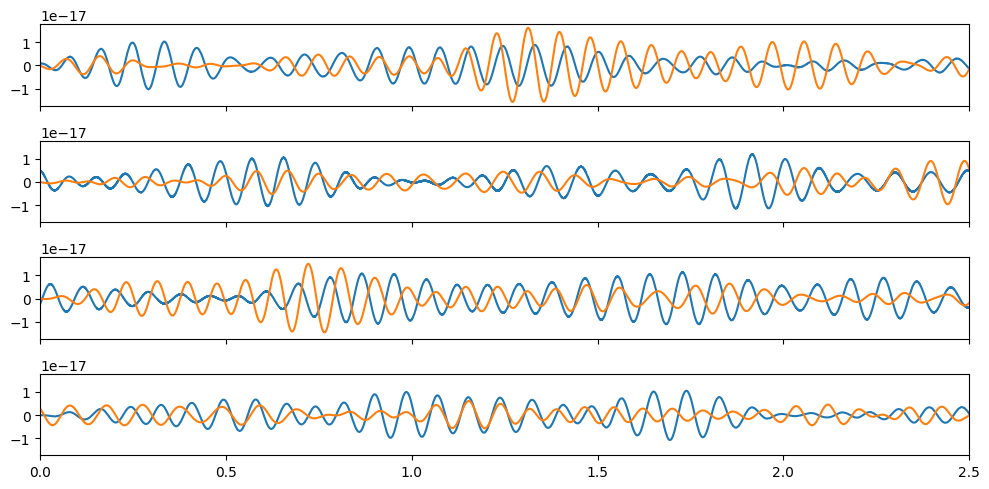

In [22]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(batch_size, sharex=True, sharey=True, figsize=(10, 5))

for i in range(batch_size):
    ax[i].plot(time, data[i, 0, :])
    ax[i].plot(time, data[i, 1, :])

ax[0].set_xlim(time.min(), time.max())
plt.tight_layout()